# Step 9 — Convert findings into diagnostics

This notebook turns the validated findings into practical diagnostic
outputs. Every diagnostic contains:

- a **ranked bottleneck**;
- **supporting evidence**;
- **possible causes**;
- a **recommended test**;
- a **KPI** and success signal.

Three separate outputs are created:

1. startup health diagnostics from runway and unit economics;
2. sector risk hypotheses from historical failure records;
3. funding-position diagnostics from comparable Crunchbase cohorts.

## Important scope rule

The three datasets are not joined at company level because verified
matches do not exist. Bottlenecks are ranked **within each valid data
source**, not across unrelated companies.

- Synthetic metrics demonstrate the startup-level diagnostic workflow.
- Failure records provide historical hypotheses, not failure
  probabilities.
- Funding position provides a peer benchmark, not proof of capital
  adequacy or causation.

In [1]:
# Import the small set of libraries needed for this step.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RULE_VERSION = "1.0"
RANDOM_SEED = 42

# Find the project from the project root, notebooks folder,
# or the demonstration workspace used to build this notebook.
BASE_DIR = Path.cwd()
if not (BASE_DIR / "data" / "processed").exists():
    if (BASE_DIR.parent / "data" / "processed").exists():
        BASE_DIR = BASE_DIR.parent
    elif (BASE_DIR / "step4_test_project" / "data" / "processed").exists():
        BASE_DIR = BASE_DIR / "step4_test_project"

PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURE_DIR = BASE_DIR / "outputs" / "figures"
TABLE_DIR = BASE_DIR / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")


def save_figure(file_name):
    # Save the chart and show it in the notebook.
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / file_name, dpi=150, bbox_inches="tight")
    plt.show()


def format_usd(value):
    # Make large funding values easier to read.
    if pd.isna(value):
        return "Missing"
    if value >= 1_000_000_000:
        return "$" + f"{value / 1_000_000_000:.2f}B"
    if value >= 1_000_000:
        return "$" + f"{value / 1_000_000:.2f}M"
    if value >= 1_000:
        return "$" + f"{value / 1_000:.1f}K"
    return "$" + f"{value:,.0f}"

## Load the analysis tables and validation summary

In [2]:
failure_file = PROCESSED_DIR / "failure_feature_table.csv"
crunchbase_file = PROCESSED_DIR / "crunchbase_feature_table.csv"
metrics_file = PROCESSED_DIR / "startup_metrics_feature_table.csv"
validation_file = TABLE_DIR / "step8_validation_summary.csv"

required_files = [
    failure_file,
    crunchbase_file,
    metrics_file,
    validation_file,
]
missing_files = [str(file) for file in required_files if not file.exists()]

if missing_files:
    raise FileNotFoundError(
        f"Missing required files: {missing_files}. Run Steps 5 and 8 first."
    )

failure = pd.read_csv(failure_file, low_memory=False)
crunchbase = pd.read_csv(crunchbase_file, low_memory=False)
startup_metrics = pd.read_csv(metrics_file)
validation_summary = pd.read_csv(validation_file)

print(f"Failure records:        {len(failure):,}")
print(f"Crunchbase companies:   {len(crunchbase):,}")
print(f"Synthetic metric rows:  {len(startup_metrics):,}")
print()
print("Step 8 conclusions used in this step:")
print(validation_summary[["Finding", "Conclusion"]].to_string(index=False))

Failure records:        409
Crunchbase companies:   66,368
Synthetic metric rows:  200

Step 8 conclusions used in this step:
                   Finding                                                            Conclusion
Health-risk classification              Stable descriptive rule; predictive validity not tested.
         Failure archetype      Broad archetype is stable; detailed sector claims are tentative.
 Funding-outcome benchmark Useful benchmark signal; not a standalone prediction or causal claim.


**Note.** Step 8 supports using these findings as diagnostic signals, but
not as causal conclusions. Step 9 therefore uses wording such as
*possible bottleneck*, *historical risk*, and *recommended test*.

## Diagnostic output structure

| Field | Meaning |
|---|---|
| Bottleneck rank | Investigation order within the startup, sector, or peer benchmark |
| Ranked bottleneck | The issue to investigate |
| Priority | Critical, High, Watch, Investigate, or Monitor |
| Supporting evidence | The observed metric or historical prevalence |
| Possible causes | Plausible explanations to test, not proven causes |
| Recommended test | A focused next analysis or experiment |
| KPI | The main measure used to judge the result |
| Success signal | A practical decision threshold |
| Evidence limit | What the dataset cannot establish |

# 1. Startup health diagnostics

Each synthetic startup receives up to two ranked bottlenecks.

**Cash runway score**

- Critical: under 3 months
- High: 3 to under 6 months
- Watch: 6 to under 12 months
- No immediate breach: 12 months or more

**Unit-economics score**

- Critical: LTV/CAC at or below 1
- High: above 1 and at or below 2
- Watch: above 2 and at or below 3
- No immediate breach: above 3

Higher severity is ranked first. A tie is resolved in favor of runway
because Step 7 found it to be the more common immediate constraint.

In [3]:
health = startup_metrics[startup_metrics["analysis_eligible"]].copy()


def runway_priority_score(runway_months):
    if runway_months < 3:
        return 3
    if runway_months < 6:
        return 2
    if runway_months < 12:
        return 1
    return 0


def unit_economics_priority_score(ltv_cac_ratio):
    if ltv_cac_ratio <= 1:
        return 3
    if ltv_cac_ratio <= 2:
        return 2
    if ltv_cac_ratio <= 3:
        return 1
    return 0


priority_names = {
    3: "Critical",
    2: "High",
    1: "Watch",
    0: "Monitor",
}

health_rows = []

for _, startup in health.iterrows():
    runway_score = runway_priority_score(startup["runway_months"])
    unit_score = unit_economics_priority_score(
        startup["ltv_cac_ratio"]
    )

    common_fields = {
        "startup_id": startup["startup_id"],
        "stage": startup["stage"],
        "category_group": startup["category_group"],
        "health_status": startup["health_status"],
    }

    if runway_score > 0:
        health_rows.append({
            **common_fields,
            "ranked_bottleneck": "Cash runway",
            "priority_score": runway_score,
            "tie_order": 0,
            "priority": priority_names[runway_score],
            "supporting_evidence":
                f"Runway is {startup['runway_months']:.1f} months; "
                "12 months is the no-immediate-breach threshold.",
            "possible_causes":
                "High burn, limited cash, slow collections, or spending "
                "ahead of revenue progress.",
            "recommended_test":
                "Build a 13-week cash plan and test the three largest "
                "realistic burn reductions.",
            "KPI": "Runway months",
            "success_signal":
                "Add at least 3 months of runway or reach 12 months "
                "without weakening customer metrics.",
            "evidence_limit":
                "Synthetic current-state data; no observed future outcome.",
        })

    if unit_score > 0:
        health_rows.append({
            **common_fields,
            "ranked_bottleneck": "Unit economics",
            "priority_score": unit_score,
            "tie_order": 1,
            "priority": priority_names[unit_score],
            "supporting_evidence":
                f"LTV/CAC is {startup['ltv_cac_ratio']:.2f}; "
                "a value above 3 is the strong range used here.",
            "possible_causes":
                "High acquisition cost, weak retention, low gross margin, "
                "or pricing that does not reflect delivered value.",
            "recommended_test":
                "Compare CAC and retained value by channel and customer "
                "cohort before increasing acquisition spend.",
            "KPI": "LTV/CAC ratio",
            "success_signal":
                "Reach LTV/CAC above 3 or improve it by at least 20% "
                "without reducing qualified growth.",
            "evidence_limit":
                "Synthetic current-state data; LTV quality depends on "
                "retention and margin assumptions.",
        })

    if runway_score == 0 and unit_score == 0:
        health_rows.append({
            **common_fields,
            "ranked_bottleneck": "No immediate threshold breach",
            "priority_score": 0,
            "tie_order": 2,
            "priority": "Monitor",
            "supporting_evidence":
                f"Runway is {startup['runway_months']:.1f} months and "
                f"LTV/CAC is {startup['ltv_cac_ratio']:.2f}.",
            "possible_causes":
                "No immediate issue is indicated by these two metrics; "
                "other product or market bottlenecks may still exist.",
            "recommended_test":
                "Monitor monthly trends and investigate any deterioration "
                "before adding fixed cost.",
            "KPI": "Runway months",
            "success_signal":
                "Keep runway at or above 12 months and LTV/CAC above 3.",
            "evidence_limit":
                "Only runway and LTV/CAC are considered in this health screen.",
        })

startup_diagnostics = pd.DataFrame(health_rows)
startup_diagnostics = startup_diagnostics.sort_values(
    ["startup_id", "priority_score", "tie_order"],
    ascending=[True, False, True],
)
startup_diagnostics["bottleneck_rank"] = (
    startup_diagnostics.groupby("startup_id").cumcount() + 1
)

health_output_columns = [
    "startup_id",
    "stage",
    "category_group",
    "health_status",
    "bottleneck_rank",
    "ranked_bottleneck",
    "priority",
    "supporting_evidence",
    "possible_causes",
    "recommended_test",
    "KPI",
    "success_signal",
    "evidence_limit",
]
startup_diagnostics = startup_diagnostics[health_output_columns]

health_top_summary = (
    startup_diagnostics[startup_diagnostics["bottleneck_rank"] == 1]
    .groupby(["ranked_bottleneck", "priority"])
    .size()
    .reset_index(name="startups")
)
health_top_summary["share_of_startups_pct"] = (
    100 * health_top_summary["startups"] / health["startup_id"].nunique()
).round(1)

startup_diagnostics.to_csv(
    TABLE_DIR / "step9_startup_health_diagnostics.csv", index=False
)
health_top_summary.to_csv(
    TABLE_DIR / "step9_startup_health_summary.csv", index=False
)

top_bottleneck_counts = (
    startup_diagnostics[startup_diagnostics["bottleneck_rank"] == 1]
    ["ranked_bottleneck"]
    .value_counts()
    .rename_axis("Top-ranked bottleneck")
    .reset_index(name="Startups")
)

print("Top-ranked startup bottlenecks:")
print(top_bottleneck_counts.to_string(index=False))
print()
print("Example diagnostic for STARTUP_003:")
example_columns = [
    "bottleneck_rank",
    "ranked_bottleneck",
    "priority",
    "supporting_evidence",
    "recommended_test",
    "KPI",
]
with pd.option_context("display.max_colwidth", 70):
    print(
        startup_diagnostics[
            startup_diagnostics["startup_id"] == "STARTUP_003"
        ][example_columns].to_string(index=False)
    )

Top-ranked startup bottlenecks:
        Top-ranked bottleneck  Startups
                  Cash runway       143
               Unit economics        45
No immediate threshold breach        12

Example diagnostic for STARTUP_003:
 bottleneck_rank ranked_bottleneck priority                                                   supporting_evidence                                                                                   recommended_test           KPI
               1       Cash runway Critical Runway is 0.8 months; 12 months is the no-immediate-breach threshold.                    Build a 13-week cash plan and test the three largest realistic burn reductions. Runway months
               2    Unit economics     High       LTV/CAC is 1.27; a value above 3 is the strong range used here. Compare CAC and retained value by channel and customer cohort before increasing acquisition spend. LTV/CAC ratio


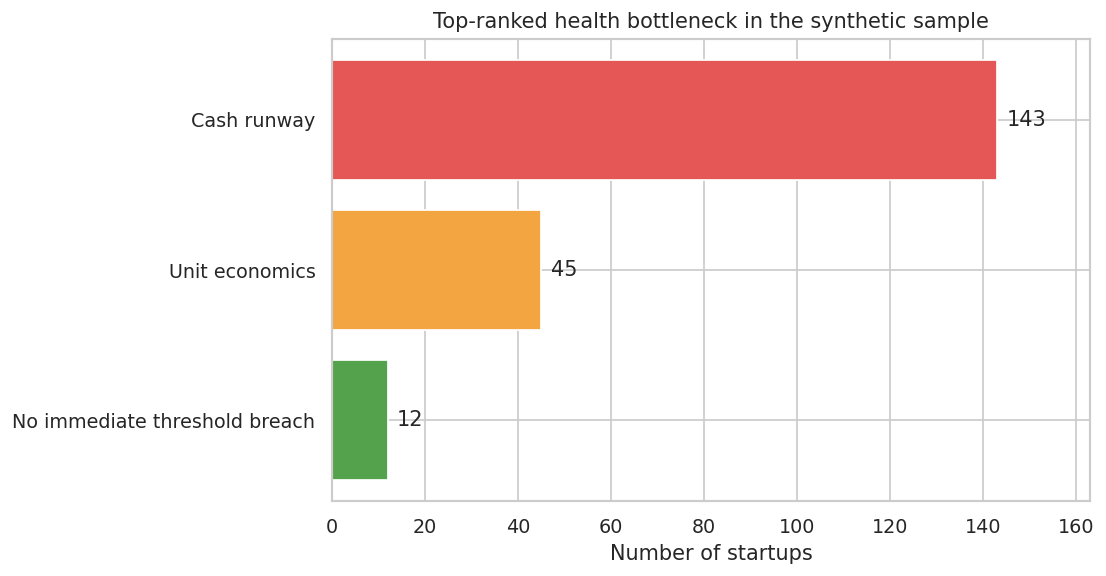

In [4]:
health_plot = top_bottleneck_counts.iloc[::-1]

plt.figure(figsize=(9, 4.8))
colors = {
    "Cash runway": "#E45756",
    "Unit economics": "#F2A541",
    "No immediate threshold breach": "#54A24B",
}
plt.barh(
    health_plot["Top-ranked bottleneck"],
    health_plot["Startups"],
    color=[colors[value] for value in health_plot["Top-ranked bottleneck"]],
)
plt.title("Top-ranked health bottleneck in the synthetic sample")
plt.xlabel("Number of startups")
plt.ylabel("")

for position, value in enumerate(health_plot["Startups"]):
    plt.text(value + 2, position, str(value), va="center")

plt.xlim(0, max(health_plot["Startups"]) + 20)
save_figure("step9_01_health_diagnostics.png")

**Diagnostic note.** Cash runway is the first-ranked bottleneck for 143
of 200 synthetic startups. Unit economics ranks first for 45 startups,
and 12 have no immediate threshold breach. This ranking determines the
investigation order; it does not predict failure.

# 2. Sector failure-risk diagnostics

For each sector, the notebook ranks three historical signals by their
prevalence among failed startups. The combined **Large incumbent plus
Competition** signal is treated as one competitive-pressure bottleneck.

These rows are hypotheses to test with the client's own customer and
operating evidence. They are not sector failure probabilities.

In [5]:
# Each historical factor is linked to a practical test and KPI.
sector_actions = {
    "Competitive pressure": {
        "possible_causes":
            "Weak differentiation, incumbent distribution advantage, "
            "high switching cost, or an unclear target segment.",
        "recommended_test":
            "Run ten segment-specific win/loss interviews and compare "
            "why customers choose the startup or an incumbent.",
        "KPI": "Target-segment win rate",
        "success_signal":
            "Win rate improves after a specific positioning or product test.",
    },
    "No Budget": {
        "possible_causes":
            "Burn exceeds financing capacity, margins are weak, or the "
            "plan requires more capital than expected.",
        "recommended_test":
            "Build base and downside cash scenarios through the next "
            "product or revenue milestone.",
        "KPI": "Runway months",
        "success_signal":
            "A funded plan reaches the next milestone with a cash buffer.",
    },
    "Poor Market Fit": {
        "possible_causes":
            "Low problem urgency, wrong segment, weak willingness to pay, "
            "or a solution that does not fit the workflow.",
        "recommended_test":
            "Run problem and willingness-to-pay interviews in one clearly "
            "defined customer segment.",
        "KPI": "Target-segment activation rate",
        "success_signal":
            "Activation and retained use improve in the tested segment.",
    },
    "Acquisition Stagnation": {
        "possible_causes":
            "Weak channel fit, poor conversion, slow activation, or early "
            "customer churn.",
        "recommended_test":
            "Measure the acquisition-to-activation funnel by channel and "
            "pause the weakest channel.",
        "KPI": "Qualified activation rate",
        "success_signal":
            "Activation rises while CAC remains stable or falls.",
    },
    "High Operational Costs": {
        "possible_causes":
            "Low gross margin, expensive delivery, unused capacity, or "
            "high support requirements.",
        "recommended_test":
            "Calculate contribution margin by product or customer segment "
            "and redesign the largest cost driver.",
        "KPI": "Contribution margin (%)",
        "success_signal":
            "Contribution margin improves without reducing retained value.",
    },
    "Monetization Failure": {
        "possible_causes":
            "Pricing does not match value, packaging is confusing, or free "
            "usage does not convert.",
        "recommended_test":
            "Test two pricing or packaging options with a defined customer "
            "segment.",
        "KPI": "Paid conversion rate",
        "success_signal":
            "Paid conversion improves without a material retention decline.",
    },
    "Niche Limits": {
        "possible_causes":
            "The addressable segment is small, demand is infrequent, or the "
            "use case does not extend to adjacent customers.",
        "recommended_test":
            "Test the same value proposition with one adjacent segment and "
            "compare qualified demand.",
        "KPI": "Qualified demand per segment",
        "success_signal":
            "An adjacent segment produces repeatable qualified demand.",
    },
    "Execution Flaws": {
        "possible_causes":
            "Slow delivery, unclear ownership, product defects, or too many "
            "competing priorities.",
        "recommended_test":
            "Track one delivery cycle from commitment to customer value and "
            "remove the largest delay.",
        "KPI": "Time to customer value",
        "success_signal":
            "Cycle time falls while defect or rework rates do not increase.",
    },
    "Trend Shifts": {
        "possible_causes":
            "Customer behavior, technology, regulation, or preferred channels "
            "have changed.",
        "recommended_test":
            "Repeat customer discovery around changed workflows and compare "
            "current demand with the original use case.",
        "KPI": "Retained usage rate",
        "success_signal":
            "The revised use case produces stable or improving retained use.",
    },
    "Platform Dependency": {
        "possible_causes":
            "A platform controls distribution, pricing, access, or product "
            "functionality.",
        "recommended_test":
            "Test one owned acquisition or delivery path that reduces reliance "
            "on the external platform.",
        "KPI": "Share of activity from owned channels",
        "success_signal":
            "Owned-channel share rises without unacceptable acquisition cost.",
    },
    "Toxicity/Trust Issues": {
        "possible_causes":
            "Safety concerns, poor moderation, privacy concerns, or unreliable "
            "service reduce trust.",
        "recommended_test":
            "Classify complaints and churn reasons, then fix the most frequent "
            "trust-breaking event.",
        "KPI": "Trust-related complaint rate",
        "success_signal":
            "Trust complaints and related churn decline.",
    },
    "Regulatory Pressure": {
        "possible_causes":
            "Compliance cost, approval delays, market restrictions, or unclear "
            "regulatory ownership.",
        "recommended_test":
            "Map the minimum compliant route to market and validate it with a "
            "qualified adviser.",
        "KPI": "Time to compliance milestone",
        "success_signal":
            "The next compliance milestone is reached on time and within budget.",
    },
    "Overhype": {
        "possible_causes":
            "Expectations exceed delivered value or marketing attracts the "
            "wrong customer profile.",
        "recommended_test":
            "Compare promised outcomes with achieved outcomes for newly "
            "activated customers.",
        "KPI": "Promise-to-value completion rate",
        "success_signal":
            "More customers achieve the promised value within the target time.",
    },
}

secondary_flags = [
    "No Budget",
    "Poor Market Fit",
    "Acquisition Stagnation",
    "Platform Dependency",
    "High Operational Costs",
    "Monetization Failure",
    "Niche Limits",
    "Execution Flaws",
    "Trend Shifts",
    "Toxicity/Trust Issues",
    "Regulatory Pressure",
    "Overhype",
]

sector_rows = []

for sector, sector_data in failure.groupby("Sector"):
    signal_rates = {
        "Competitive pressure": 100 * (
            sector_data["Giants"].eq(1)
            & sector_data["Competition"].eq(1)
        ).mean()
    }

    for factor in secondary_flags:
        if sector_data[factor].notna().any():
            signal_rates[factor] = 100 * sector_data[factor].mean()

    ranked_signals = sorted(
        signal_rates.items(),
        key=lambda item: (-item[1], item[0]),
    )[:3]

    for rank, (signal, prevalence) in enumerate(ranked_signals, start=1):
        action = sector_actions[signal]
        sector_rows.append({
            "Sector": sector,
            "bottleneck_rank": rank,
            "ranked_bottleneck": signal,
            "priority": "Investigate",
            "supporting_evidence":
                f"Recorded in {prevalence:.1f}% of "
                f"{len(sector_data)} failed-startup records in this sector.",
            "historical_prevalence_pct": round(prevalence, 1),
            "sector_failure_records": len(sector_data),
            "possible_causes": action["possible_causes"],
            "recommended_test": action["recommended_test"],
            "KPI": action["KPI"],
            "success_signal": action["success_signal"],
            "evidence_limit":
                "Failure-only historical data; this is a hypothesis, not a "
                "sector failure probability or causal estimate.",
        })

sector_diagnostics = pd.DataFrame(sector_rows)
sector_diagnostics = sector_diagnostics.sort_values(
    ["Sector", "bottleneck_rank"]
)
sector_diagnostics.to_csv(
    TABLE_DIR / "step9_sector_failure_diagnostics.csv", index=False
)

sector_top = sector_diagnostics[
    sector_diagnostics["bottleneck_rank"] == 1
][[
    "Sector",
    "ranked_bottleneck",
    "historical_prevalence_pct",
    "recommended_test",
    "KPI",
]]

with pd.option_context("display.max_colwidth", 60):
    print("First-ranked historical signal by sector:")
    print(sector_top.to_string(index=False))

First-ranked historical signal by sector:
                         Sector    ranked_bottleneck  historical_prevalence_pct                                                                                           recommended_test                          KPI
Accommodation and Food Services Competitive pressure                       65.4 Run ten segment-specific win/loss interviews and compare why customers choose the startup or an incumbent.      Target-segment win rate
          Finance and Insurance Competitive pressure                       95.7 Run ten segment-specific win/loss interviews and compare why customers choose the startup or an incumbent.      Target-segment win rate
                    Health Care Competitive pressure                       56.7 Run ten segment-specific win/loss interviews and compare why customers choose the startup or an incumbent.      Target-segment win rate
                    Information Competitive pressure                       58.3 Run ten segmen

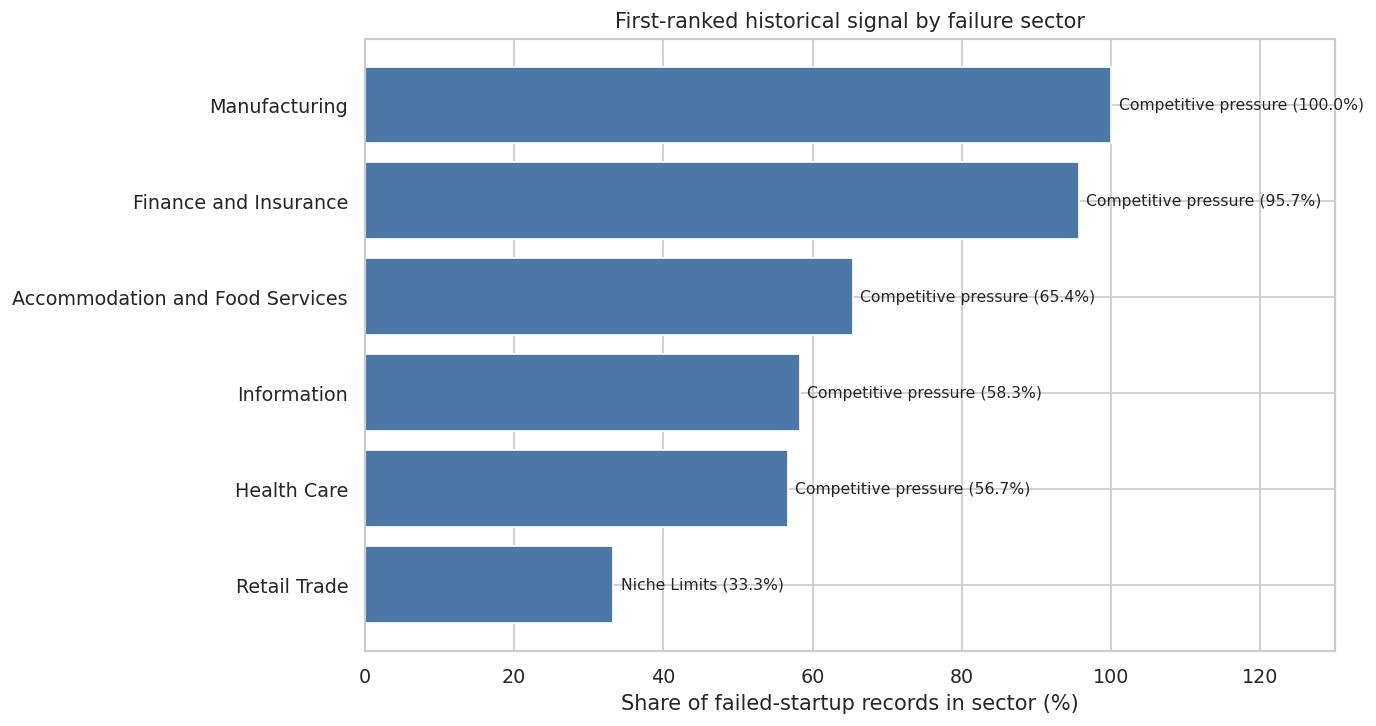

In [6]:
sector_plot = sector_top.sort_values("historical_prevalence_pct").copy()

plt.figure(figsize=(11, 6))
plt.barh(
    sector_plot["Sector"],
    sector_plot["historical_prevalence_pct"],
    color="#4C78A8",
)
plt.title("First-ranked historical signal by failure sector")
plt.xlabel("Share of failed-startup records in sector (%)")
plt.ylabel("")

for position, (_, row) in enumerate(sector_plot.iterrows()):
    label = f"{row['ranked_bottleneck']} ({row['historical_prevalence_pct']:.1f}%)"
    plt.text(
        row["historical_prevalence_pct"] + 1,
        position,
        label,
        va="center",
        fontsize=9,
    )

plt.xlim(0, 130)
save_figure("step9_02_sector_diagnostics.png")

**Diagnostic note.** Competitive pressure is the first-ranked historical
signal in five of six sectors. Niche limits ranks first in Retail Trade.
Step 8 showed that the broad competitive pattern is stable, while some
sector-level factors change across samples. Founders should therefore use
these rows to choose an investigation, then confirm the issue using their
own evidence.

# 3. Funding-position diagnostics

The Step 7 peer cohort is reconstructed using:

**Primary category + country + founding-period cohort**

Only cohorts with at least 30 companies with reported funding and at
least 5 observed acquisitions or IPOs are used. Each company receives one
funding diagnostic. It is ranked first only within the funding evidence
stream.

In [7]:
funding_base = crunchbase[
    crunchbase["funding_total_usd"].notna()
    & crunchbase["primary_category"].ne("Unknown")
    & crunchbase["country_code"].ne("UNKNOWN")
    & crunchbase["founded_cohort"].ne("Unknown")
].copy()
funding_base["observed_exit"] = funding_base["status"].isin(
    ["acquired", "ipo"]
)

cohort_eligibility = (
    funding_base.groupby("peer_cohort")
    .agg(
        funding_records=("name", "size"),
        observed_exit_records=("observed_exit", "sum"),
    )
)
eligible_cohorts = cohort_eligibility[
    (cohort_eligibility["funding_records"] >= 30)
    & (cohort_eligibility["observed_exit_records"] >= 5)
].index

funding = funding_base[
    funding_base["peer_cohort"].isin(eligible_cohorts)
].copy()

funding["funding_percentile"] = (
    funding.groupby("peer_cohort")["funding_total_usd"]
    .rank(pct=True, method="average")
)

cohort_funding_stats = (
    funding.groupby("peer_cohort")["funding_total_usd"]
    .agg(
        peer_q1_usd=lambda values: values.quantile(0.25),
        peer_median_usd="median",
        peer_q3_usd=lambda values: values.quantile(0.75),
    )
    .reset_index()
)
funding = funding.merge(cohort_funding_stats, on="peer_cohort")

funding["funding_position"] = np.select(
    [
        funding["funding_percentile"] <= 0.25,
        funding["funding_percentile"] > 0.75,
    ],
    [
        "Below peer Q1",
        "Above peer Q3",
    ],
    default="Within peer middle 50%",
)

funding_actions = {
    "Below peer Q1": {
        "ranked_bottleneck": "Possible funding constraint",
        "priority": "Investigate",
        "possible_causes":
            "Limited capital access, milestones not yet proven, or an "
            "operating plan that requires more cash than peers.",
        "recommended_test":
            "Build a 13-week cash plan and calculate the funding required "
            "to reach the next proof point.",
        "KPI": "Funding gap to next milestone",
        "success_signal":
            "The plan reaches the next milestone with a defined cash buffer.",
    },
    "Within peer middle 50%": {
        "ranked_bottleneck": "Capital productivity",
        "priority": "Monitor",
        "possible_causes":
            "Capital may be adequate, while milestone execution or the "
            "conversion of spending into traction may be limiting progress.",
        "recommended_test":
            "Compare quarterly milestone progress with cash consumed and "
            "identify spending that does not move the next milestone.",
        "KPI": "Burn multiple",
        "success_signal":
            "Burn multiple improves while the next operating milestone is met.",
    },
    "Above peer Q3": {
        "ranked_bottleneck": "Possible capital inefficiency",
        "priority": "Investigate",
        "possible_causes":
            "High fixed cost, a long development cycle, expansion ahead of "
            "traction, or a legitimately capital-intensive model.",
        "recommended_test":
            "Test whether incremental capital produced proportional revenue, "
            "retention, or milestone progress.",
        "KPI": "Revenue growth per $1M of funding",
        "success_signal":
            "Incremental capital produces improving growth or milestone output.",
    },
}

funding_rows = []

for _, company in funding.iterrows():
    position = company["funding_position"]
    action = funding_actions[position]

    funding_rows.append({
        "name": company["name"],
        "primary_category": company["primary_category"],
        "country_code": company["country_code"],
        "founded_cohort": company["founded_cohort"],
        "status": company["status"],
        "peer_cohort": company["peer_cohort"],
        "bottleneck_rank": 1,
        "ranked_bottleneck": action["ranked_bottleneck"],
        "priority": action["priority"],
        "supporting_evidence":
            f"Funding is {format_usd(company['funding_total_usd'])}; "
            f"peer Q1 {format_usd(company['peer_q1_usd'])}, "
            f"median {format_usd(company['peer_median_usd'])}, and "
            f"Q3 {format_usd(company['peer_q3_usd'])}; "
            f"peer percentile {100 * company['funding_percentile']:.1f}%.",
        "funding_position": position,
        "funding_total_usd": company["funding_total_usd"],
        "funding_percentile": company["funding_percentile"],
        "possible_causes": action["possible_causes"],
        "recommended_test": action["recommended_test"],
        "KPI": action["KPI"],
        "success_signal": action["success_signal"],
        "evidence_limit":
            "Observational benchmark; funding may follow traction and does "
            "not prove capital adequacy or cause the observed status.",
    })

funding_diagnostics = pd.DataFrame(funding_rows)
funding_diagnostics.to_csv(
    TABLE_DIR / "step9_funding_diagnostics.csv", index=False
)

funding_position_summary = (
    funding_diagnostics["funding_position"]
    .value_counts()
    .rename_axis("funding_position")
    .reset_index(name="companies")
)
funding_position_summary["share_pct"] = (
    100 * funding_position_summary["companies"]
    / len(funding_diagnostics)
).round(1)
funding_position_summary.to_csv(
    TABLE_DIR / "step9_funding_diagnostic_summary.csv", index=False
)

print(f"Eligible peer cohorts: {len(eligible_cohorts):,}")
print(f"Companies with a funding diagnostic: {len(funding_diagnostics):,}")
print()
print(funding_position_summary.to_string(index=False))
print()
print("One example from each funding position:")
funding_examples = (
    funding_diagnostics.sort_values(["funding_position", "name"])
    .groupby("funding_position", as_index=False)
    .head(1)
)
example_columns = [
    "name",
    "funding_position",
    "ranked_bottleneck",
    "supporting_evidence",
    "recommended_test",
    "KPI",
]
with pd.option_context("display.max_colwidth", 65):
    print(funding_examples[example_columns].to_string(index=False))

Eligible peer cohorts: 97
Companies with a funding diagnostic: 15,878

      funding_position  companies  share_pct
Within peer middle 50%       7944       50.0
         Above peer Q3       4015       25.3
         Below peer Q1       3919       24.7

One example from each funding position:
         name       funding_position             ranked_bottleneck                                                                       supporting_evidence                                                                                                     recommended_test                               KPI
.Club Domains          Above peer Q3 Possible capital inefficiency  Funding is $7.00M; peer Q1 $250.0K, median $1.15M, and Q3 $3.58M; peer percentile 84.1%.                    Test whether incremental capital produced proportional revenue, retention, or milestone progress. Revenue growth per $1M of funding
  10-20 Media          Below peer Q1   Possible funding constraint Funding is $2.05M; peer Q

**Diagnostic note.** The funding output covers 97 eligible peer cohorts
and 15,878 companies. A position below peer Q1 triggers a possible funding
constraint test. A position above peer Q3 triggers a capital-productivity
test. Neither position proves that the company has too little or too much
capital; current cash, burn, milestones, and traction must be collected.

# Diagnostic summary and rule documentation

In [8]:
# Save the decision rules in a simple, readable table.
health_rule_rows = [
    ["Startup health", "Cash runway", "Runway under 3 months", "Critical", 3],
    ["Startup health", "Cash runway", "Runway 3 to under 6 months", "High", 2],
    ["Startup health", "Cash runway", "Runway 6 to under 12 months", "Watch", 1],
    ["Startup health", "Unit economics", "LTV/CAC at or below 1", "Critical", 3],
    ["Startup health", "Unit economics", "LTV/CAC above 1 to 2", "High", 2],
    ["Startup health", "Unit economics", "LTV/CAC above 2 to 3", "Watch", 1],
]
health_rule_table = pd.DataFrame(
    health_rule_rows,
    columns=[
        "rule_group",
        "diagnostic",
        "condition",
        "priority",
        "priority_score",
    ],
)

funding_rule_rows = [
    [
        "Funding benchmark",
        "Possible funding constraint",
        "Funding percentile at or below 25% inside eligible peer cohort",
        "Investigate",
        1,
    ],
    [
        "Funding benchmark",
        "Capital productivity",
        "Funding percentile above 25% and at or below 75%",
        "Monitor",
        1,
    ],
    [
        "Funding benchmark",
        "Possible capital inefficiency",
        "Funding percentile above 75% inside eligible peer cohort",
        "Investigate",
        1,
    ],
]
funding_rule_table = pd.DataFrame(
    funding_rule_rows,
    columns=health_rule_table.columns,
)

sector_rule_table = pd.DataFrame({
    "rule_group": "Historical sector risk",
    "diagnostic": list(sector_actions.keys()),
    "condition":
        "Rank among the three most prevalent recorded signals in sector",
    "priority": "Investigate",
    "priority_score": np.nan,
})

diagnostic_rules = pd.concat(
    [health_rule_table, funding_rule_table, sector_rule_table],
    ignore_index=True,
)
diagnostic_rules["rule_version"] = RULE_VERSION
diagnostic_rules.to_csv(
    TABLE_DIR / "step9_diagnostic_rules.csv", index=False
)

overall_competitive_share = 100 * (
    failure["Giants"].eq(1) & failure["Competition"].eq(1)
).mean()

diagnostic_summary = pd.DataFrame([
    {
        "Evidence stream": "Synthetic startup health",
        "First diagnostic": "Cash runway",
        "Supporting evidence":
            "Cash runway ranks first for 143 of 200 synthetic startups.",
        "Recommended test":
            "Build a 13-week cash plan and test the largest realistic "
            "burn reductions.",
        "KPI": "Runway months",
        "Evidence limit": "Synthetic data; no future outcome.",
    },
    {
        "Evidence stream": "Historical startup failures",
        "First diagnostic": "Competitive pressure",
        "Supporting evidence":
            f"Large incumbents and competition co-occur in "
            f"{overall_competitive_share:.1f}% of failure records.",
        "Recommended test":
            "Run segment-specific win/loss interviews and test sharper "
            "differentiation.",
        "KPI": "Target-segment win rate",
        "Evidence limit": "Failure-only data; no causal estimate.",
    },
    {
        "Evidence stream": "Crunchbase funding benchmark",
        "First diagnostic": "Relative funding position",
        "Supporting evidence":
            "Step 8 found an 18.6-point top-versus-bottom observed-exit "
            "gap, with modest predictive performance.",
        "Recommended test":
            "Combine peer funding position with the company's burn, cash, "
            "traction, and next milestone.",
        "KPI": "Funding gap or burn multiple",
        "Evidence limit": "Observational association; not causation.",
    },
])
diagnostic_summary.to_csv(
    TABLE_DIR / "step9_diagnostic_summary.csv", index=False
)

with pd.option_context("display.max_colwidth", 65):
    print(diagnostic_summary.to_string(index=False))

             Evidence stream          First diagnostic                                                                                 Supporting evidence                                                                           Recommended test                          KPI                            Evidence limit
    Synthetic startup health               Cash runway                                          Cash runway ranks first for 143 of 200 synthetic startups.                  Build a 13-week cash plan and test the largest realistic burn reductions.                Runway months        Synthetic data; no future outcome.
 Historical startup failures      Competitive pressure                              Large incumbents and competition co-occur in 58.2% of failure records.                 Run segment-specific win/loss interviews and test sharper differentiation.      Target-segment win rate    Failure-only data; no causal estimate.
Crunchbase funding benchmark Relative funding pos

**Summary note.** These three first diagnostics should not be interpreted
as one global ranking. They come from different populations. In a real
client engagement, the startup's verified metrics, sector, and comparable
peer cohort would be assembled before producing one integrated ranking.

# Reproducibility checks

In [9]:
required_diagnostic_fields = [
    "bottleneck_rank",
    "ranked_bottleneck",
    "supporting_evidence",
    "possible_causes",
    "recommended_test",
    "KPI",
]

# Confirm every synthetic startup has a first-ranked diagnostic.
assert startup_diagnostics["startup_id"].nunique() == 200
assert (
    startup_diagnostics.groupby("startup_id")["bottleneck_rank"].min()
    == 1
).all()

# Confirm every sector has exactly three ranked historical signals.
assert failure["Sector"].nunique() == 6
assert (
    sector_diagnostics.groupby("Sector")["bottleneck_rank"].count()
    == 3
).all()

# Confirm the funding benchmark matches the validated Step 7 population.
assert len(eligible_cohorts) == 97
assert len(funding_diagnostics) == 15_878

# Confirm the requested diagnostic fields are complete.
for table in [
    startup_diagnostics,
    sector_diagnostics,
    funding_diagnostics,
]:
    assert table[required_diagnostic_fields].notna().all().all()

reproducibility_manifest = pd.DataFrame([
    {
        "item_type": "Input",
        "name": "startup_metrics_feature_table.csv",
        "rows": len(startup_metrics),
        "rule_version": RULE_VERSION,
        "note": "Synthetic startup operating metrics",
    },
    {
        "item_type": "Input",
        "name": "failure_feature_table.csv",
        "rows": len(failure),
        "rule_version": RULE_VERSION,
        "note": "Historical failed-startup factors",
    },
    {
        "item_type": "Input",
        "name": "crunchbase_feature_table.csv",
        "rows": len(crunchbase),
        "rule_version": RULE_VERSION,
        "note": "Startup funding and observed status",
    },
    {
        "item_type": "Output",
        "name": "step9_startup_health_diagnostics.csv",
        "rows": len(startup_diagnostics),
        "rule_version": RULE_VERSION,
        "note": "Ranked startup health bottlenecks",
    },
    {
        "item_type": "Output",
        "name": "step9_sector_failure_diagnostics.csv",
        "rows": len(sector_diagnostics),
        "rule_version": RULE_VERSION,
        "note": "Top three historical risk hypotheses by sector",
    },
    {
        "item_type": "Output",
        "name": "step9_funding_diagnostics.csv",
        "rows": len(funding_diagnostics),
        "rule_version": RULE_VERSION,
        "note": "Funding-position diagnostic for eligible peer cohorts",
    },
])

reproducibility_manifest.to_csv(
    TABLE_DIR / "step9_reproducibility_manifest.csv", index=False
)

print("All reproducibility checks passed.")
print()
print(reproducibility_manifest.to_string(index=False))

All reproducibility checks passed.

item_type                                 name  rows rule_version                                                  note
    Input    startup_metrics_feature_table.csv   200          1.0                   Synthetic startup operating metrics
    Input            failure_feature_table.csv   409          1.0                     Historical failed-startup factors
    Input         crunchbase_feature_table.csv 66368          1.0                   Startup funding and observed status
   Output step9_startup_health_diagnostics.csv   291          1.0                     Ranked startup health bottlenecks
   Output step9_sector_failure_diagnostics.csv    18          1.0        Top three historical risk hypotheses by sector
   Output        step9_funding_diagnostics.csv 15878          1.0 Funding-position diagnostic for eligible peer cohorts


## How to reproduce or update the diagnostics

1. Run Steps 4, 5, and 8 first.
2. Run this notebook from top to bottom.
3. Change thresholds only in the documented health or funding rule cells.
4. Keep the three source tables separate unless company matches are
   independently verified.
5. Review the generated CSV files in `outputs/tables`.

Generated files:

- `step9_startup_health_diagnostics.csv`
- `step9_sector_failure_diagnostics.csv`
- `step9_funding_diagnostics.csv`
- `step9_diagnostic_summary.csv`
- `step9_diagnostic_rules.csv`
- `step9_reproducibility_manifest.csv`

## Final practical use

For a real startup, select the highest-ranked supported bottleneck, review
the evidence with the founders, run the recommended test, and update the
stated KPI. Move to the next bottleneck only after the result is measured.